# Лабораторная работа №5

### Введение

Для выбранного датасета (датасетов) на основе материалов лекции решить следующие задачи:

1. Выберите набор данных (датасет) для решения задачи классификации или регресии.
2. В случае необходимости проведите удаление или заполнение пропусков и кодирование категориальных признаков.
3. С использованием метода train_test_split разделите выборку на обучающую и тестовую.
4. Обучите следующие ансамблевые модели:
    - две модели группы бэггинга (бэггинг или случайный лес или сверхслучайные деревья);
    - AdaBoost;
    - градиентный бустинг.
5. Оцените качество моделей с помощью одной из подходящих для задачи метрик. Сравните качество полученных моделей.

### 1) Выбор датасета
В качестве набора данных будем использовать датасет "Wine reviews". В датасете содержится информация о сортах вин. 

**Ссылка на датасет**: https://www.kaggle.com/datasets/yasserh/wine-quality-dataset/data

Датасет содержит следующие поля.
1. **fixed acidity**         - Фиксированное значение кислотности
2. **volatile acidity**      - Значение летучей кислотности
3. **citric acid**           - Значение лимонной кислоты
4. **residual sugar**        - Значение остаточного сахара
5. **chlorides**             - Количество хлоридов
6. **free sulfur dioxide**   - Количество свободного диоксида серы
7. **total sulfur dioxide**  - Общее количество диоксида серы
8. **density**               - Значение плотности
9. **pH**                    - Значение рН
10. **sulphates**            - Содержание сульфатов
11. **alcohol**              - Содержание алкоголя
12. **quality**              - Целевое качество (оценка от 0 до 10)
13. **id**                   - Номер по списку

### 2) Очистка датасета

Импортируем библиотеки с помощью команды import.

In [30]:
%matplotlib notebook
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix
from sklearn.ensemble import (BaggingClassifier, RandomForestClassifier, 
                             ExtraTreesClassifier, AdaBoostClassifier, 
                             GradientBoostingClassifier)
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import StandardScaler

Загрузим файлы датасета в помощью библиотеки Pandas. Проверим данные на предмет присутствия пропусков, выбросов и пр. Также немного преобразуем данные для более эффективного хранения памяти и удобного использования в будущем.

In [31]:
data = pd.read_csv('WineQT.csv')
data.head(10)

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,0
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,1
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,2
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,3
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,4
5,7.4,0.66,0.00,1.8,0.075,13.0,40.0,0.9978,3.51,0.56,9.4,5,5
6,7.9,0.60,0.06,1.6,0.069,15.0,59.0,0.9964,3.30,0.46,9.4,5,6
7,7.3,0.65,0.00,1.2,0.065,15.0,21.0,0.9946,3.39,0.47,10.0,7,7
8,7.8,0.58,0.02,2.0,0.073,9.0,18.0,0.9968,3.36,0.57,9.5,7,8
9,6.7,0.58,0.08,1.8,0.097,15.0,65.0,0.9959,3.28,0.54,9.2,5,10


In [32]:
# Проверка на пропуски
print("Пропуски до обработки:")
print(data.isna().sum())

Пропуски до обработки:
fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
Id                      0
dtype: int64


In [33]:
# Размер датасета - 1143 строки, 13 колонок
data.shape

(1143, 13)

In [34]:
total_count = data.shape[0]
print('Всего строк: {}'.format(total_count))
# Список колонок
# df.columns
# Список колонок с типами данных
data.dtypes

Всего строк: 1143


fixed acidity           float64
volatile acidity        float64
citric acid             float64
residual sugar          float64
chlorides               float64
free sulfur dioxide     float64
total sulfur dioxide    float64
density                 float64
pH                      float64
sulphates               float64
alcohol                 float64
quality                   int64
Id                        int64
dtype: object

In [35]:
# Основные статистики для числовых полей
print(data.describe())

       fixed acidity  volatile acidity  citric acid  residual sugar  \
count    1143.000000       1143.000000  1143.000000     1143.000000   
mean        8.311111          0.531339     0.268364        2.532152   
std         1.747595          0.179633     0.196686        1.355917   
min         4.600000          0.120000     0.000000        0.900000   
25%         7.100000          0.392500     0.090000        1.900000   
50%         7.900000          0.520000     0.250000        2.200000   
75%         9.100000          0.640000     0.420000        2.600000   
max        15.900000          1.580000     1.000000       15.500000   

         chlorides  free sulfur dioxide  total sulfur dioxide      density  \
count  1143.000000          1143.000000           1143.000000  1143.000000   
mean      0.086933            15.615486             45.914698     0.996730   
std       0.047267            10.250486             32.782130     0.001925   
min       0.012000             1.000000         

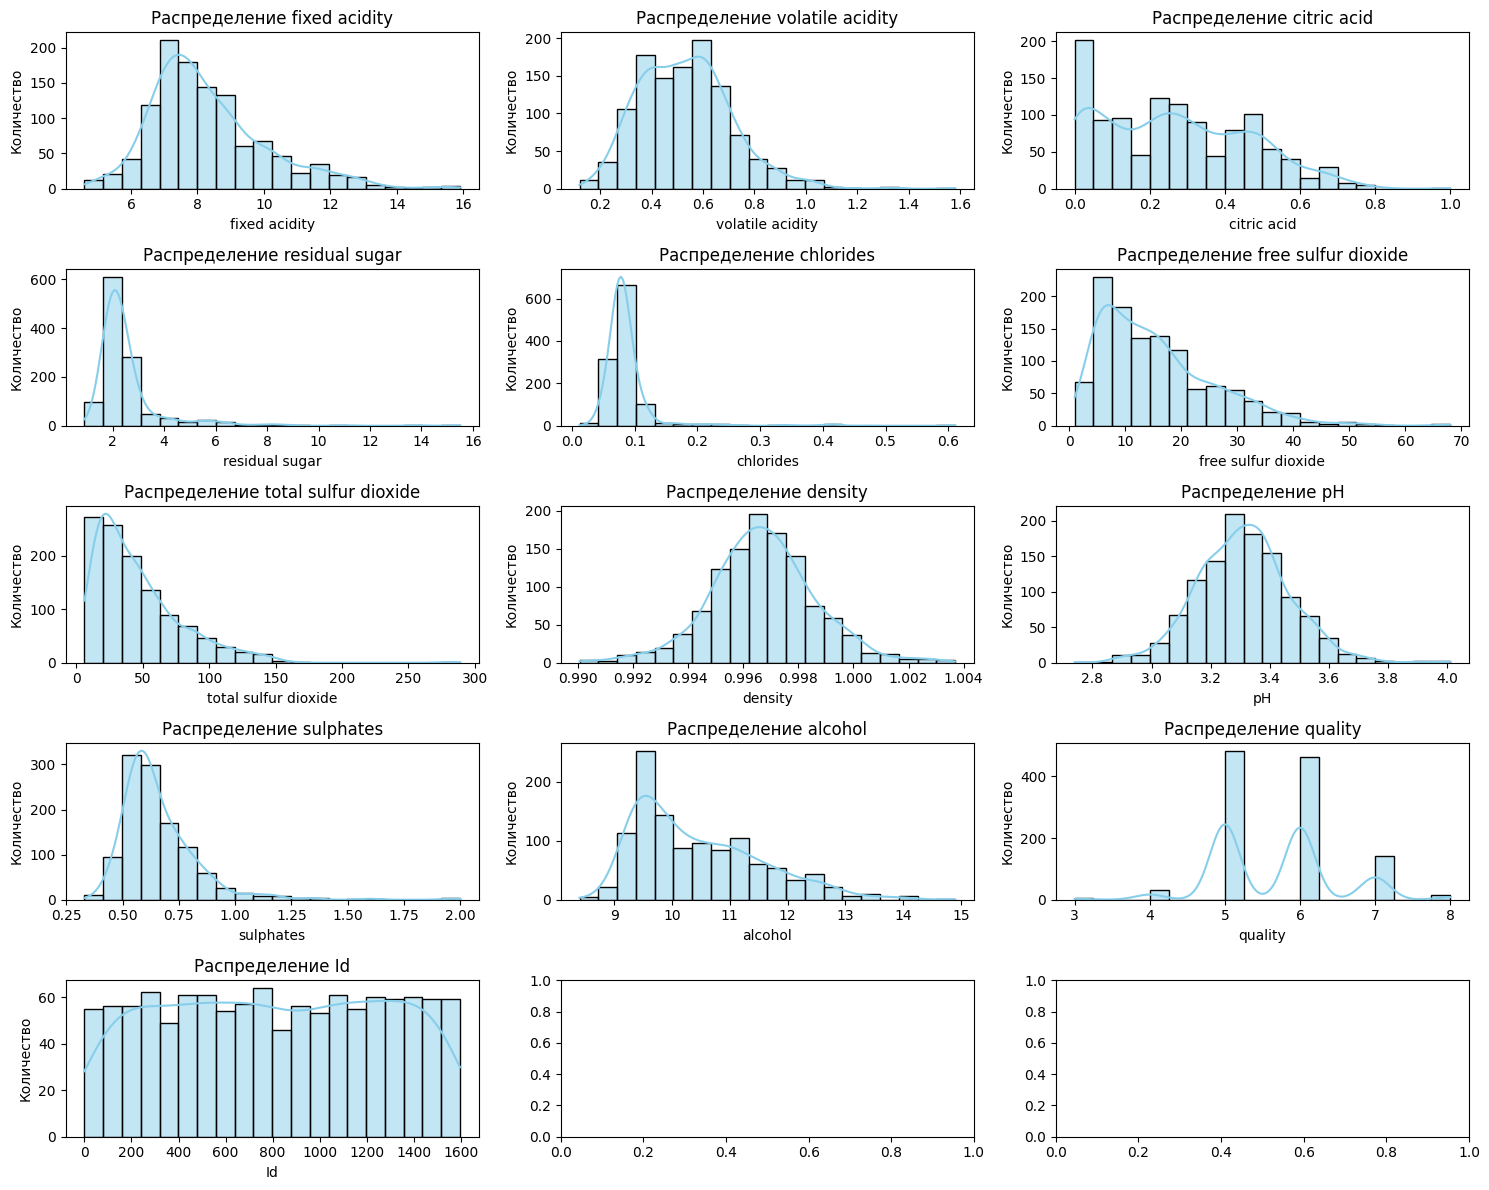

In [36]:
%matplotlib inline
# Распределение числовых признаков
num_cols = data.select_dtypes(include=['float64', 'int64']).columns
fig, axes = plt.subplots(len(num_cols) // 3 + (len(num_cols) % 3 > 0), 3, figsize=(15, 12))
axes = axes.flatten()

for ax, col in zip(axes, num_cols):
    sns.histplot(data[col], ax=ax, kde=True, bins=20, color='skyblue')
    ax.set_title(f'Распределение {col}')
    ax.set_ylabel('Количество')

plt.tight_layout()
plt.show()

In [37]:
# Описательная статистика
data.describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
count,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000
mean,8.311111,0.531339,0.268364,2.532152,0.086933,15.615486,45.914698,0.996730,3.311015,0.657708,10.442111,5.657043,804.969379
std,1.747595,0.179633,0.196686,1.355917,0.047267,10.250486,32.782130,0.001925,0.156664,0.170399,1.082196,0.805824,463.997116
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.330000,8.400000,3.000000,0.000000
25%,7.100000,0.392500,0.090000,1.900000,0.070000,7.000000,21.000000,0.995570,3.205000,0.550000,9.500000,5.000000,411.000000
50%,7.900000,0.520000,0.250000,2.200000,0.079000,13.000000,37.000000,0.996680,3.310000,0.620000,10.200000,6.000000,794.000000
75%,9.100000,0.640000,0.420000,2.600000,0.090000,21.000000,61.000000,0.997845,3.400000,0.730000,11.100000,6.000000,1209.500000
max,15.900000,1.580000,1.000000,15.500000,0.611000,68.000000,289.000000,1.003690,4.010000,2.000000,14.900000,8.000000,1597.000000


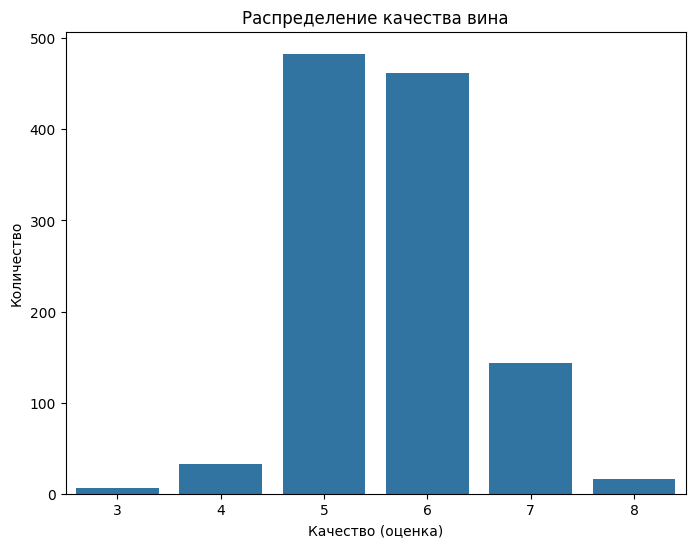

In [38]:
# Визуализация распределения целевой переменной
plt.figure(figsize=(8, 6))
sns.countplot(x='quality', data=data)
plt.title('Распределение качества вина')
plt.xlabel('Качество (оценка)')
plt.ylabel('Количество')
plt.show()

In [39]:
# Удаление ненужного столбца 'Id'
data = data.drop(columns=['Id'], errors='ignore')

In [40]:
# Проверка на дубликаты
data.duplicated().sum()

np.int64(125)

In [41]:
# Удаление дубликатов
data = data.drop_duplicates()

In [42]:
# Преобразование качества в бинарную классификацию (хорошее/плохое вино)
data['quality'] = data['quality'].apply(lambda x: 1 if x >= 7 else 0)

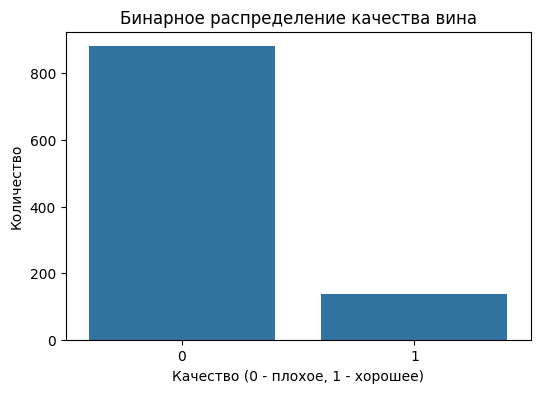

In [43]:
# Визуализация нового распределения классов
plt.figure(figsize=(6, 4))
sns.countplot(x='quality', data=data)
plt.title('Бинарное распределение качества вина')
plt.xlabel('Качество (0 - плохое, 1 - хорошее)')
plt.ylabel('Количество')
plt.show()

Данные очищены, сильных выбросов не наблюдается. Датасет можно брать в обработку.

### 3) Разделение выборки на обучающую и тестовую с использованием метода train_test_split

In [44]:
data.head(10)

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.700,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,0
1,7.8,0.880,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,0
2,7.8,0.760,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,0
3,11.2,0.280,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,0
5,7.4,0.660,0.00,1.8,0.075,13.0,40.0,0.9978,3.51,0.56,9.4,0
6,7.9,0.600,0.06,1.6,0.069,15.0,59.0,0.9964,3.30,0.46,9.4,0
7,7.3,0.650,0.00,1.2,0.065,15.0,21.0,0.9946,3.39,0.47,10.0,1
8,7.8,0.580,0.02,2.0,0.073,9.0,18.0,0.9968,3.36,0.57,9.5,1
9,6.7,0.580,0.08,1.8,0.097,15.0,65.0,0.9959,3.28,0.54,9.2,0
10,5.6,0.615,0.00,1.6,0.089,16.0,59.0,0.9943,3.58,0.52,9.9,0


In [45]:
# Разделение на признаки и целевую переменную
X = data.drop('quality', axis=1)
y = data['quality']

In [46]:
# Масштабирование признаков
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [47]:
# Разделение данных
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42, stratify=y)

In [48]:
# Проверка размеров выборок
print(f"Обучающая выборка: {X_train.shape[0]} samples")
print(f"Тестовая выборка: {X_test.shape[0]} samples")

Обучающая выборка: 814 samples
Тестовая выборка: 204 samples


### 4) Обучение следующих ансамблевых моделей.

In [49]:
models = {
    "Bagging": BaggingClassifier(
        estimator=DecisionTreeClassifier(random_state=42),
        n_estimators=100,
        random_state=42
    ),
    "Random Forest": RandomForestClassifier(
        n_estimators=100,
        random_state=42
    ),
    "Extra Trees": ExtraTreesClassifier(
        n_estimators=100,
        random_state=42
    ),
    "AdaBoost": AdaBoostClassifier(
        estimator=DecisionTreeClassifier(max_depth=1),
        n_estimators=100,
        random_state=42,
        algorithm='SAMME' 
    ),
    "Gradient Boosting": GradientBoostingClassifier(
        n_estimators=100,
        random_state=42
    )
}

In [50]:
# Обучение и предсказание для всех моделей
predictions = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    predictions[name] = model.predict(X_test)

#### 5) Оцените качество моделей с помощью одной из подходящих для задачи метрик. Сравните качество полученных моделей.

Bagging:
  Accuracy: 0.9069
  F1-score: 0.5957
  Confusion matrix:
[[171   6]
 [ 13  14]]

Random Forest:
  Accuracy: 0.9069
  F1-score: 0.5778
  Confusion matrix:
[[172   5]
 [ 14  13]]

Extra Trees:
  Accuracy: 0.8922
  F1-score: 0.5000
  Confusion matrix:
[[171   6]
 [ 16  11]]

AdaBoost:
  Accuracy: 0.8873
  F1-score: 0.5660
  Confusion matrix:
[[166  11]
 [ 12  15]]

Gradient Boosting:
  Accuracy: 0.8873
  F1-score: 0.5106
  Confusion matrix:
[[169   8]
 [ 15  12]]



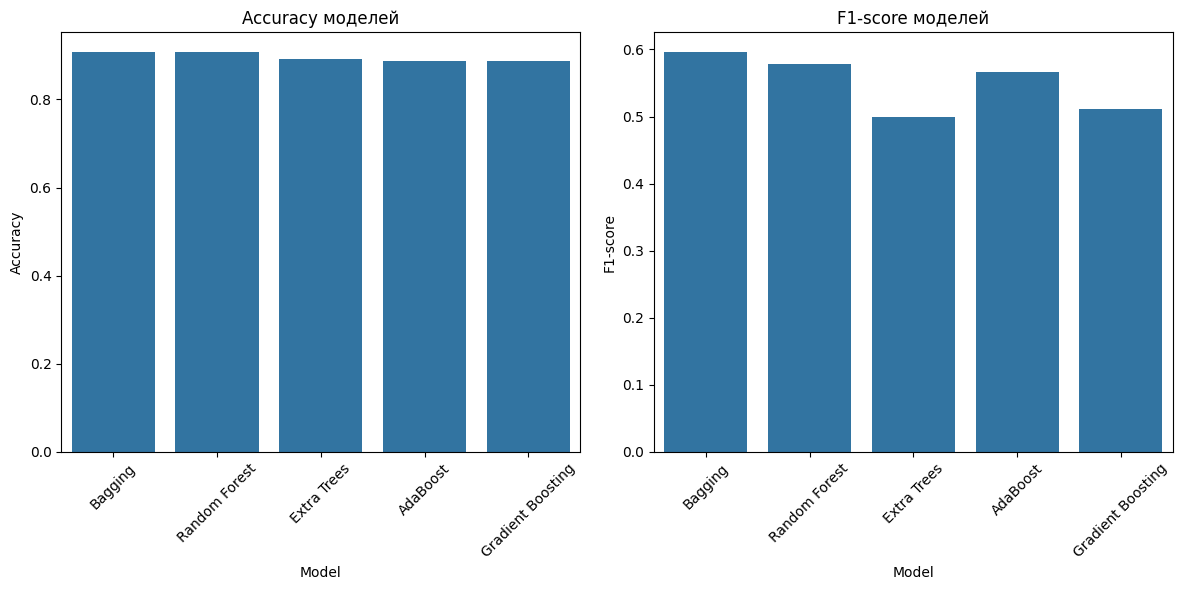

In [56]:
# 3. Оценка качества моделей с визуализацией
metrics = []
for name, pred in predictions.items():
    accuracy = accuracy_score(y_test, pred)
    f1 = f1_score(y_test, pred)
    metrics.append({
        'Model': name,
        'Accuracy': accuracy,
        'F1-score': f1
    })
    print(f"{name}:")
    print(f"  Accuracy: {accuracy:.4f}")
    print(f"  F1-score: {f1:.4f}")
    print("  Confusion matrix:")
    print(confusion_matrix(y_test, pred))
    print()

# Визуализация метрик
metrics_df = pd.DataFrame(metrics)
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
sns.barplot(x='Model', y='Accuracy', data=metrics_df)
plt.title('Accuracy моделей')
plt.xticks(rotation=45)

plt.subplot(1, 2, 2)
sns.barplot(x='Model', y='F1-score', data=metrics_df)
plt.title('F1-score моделей')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

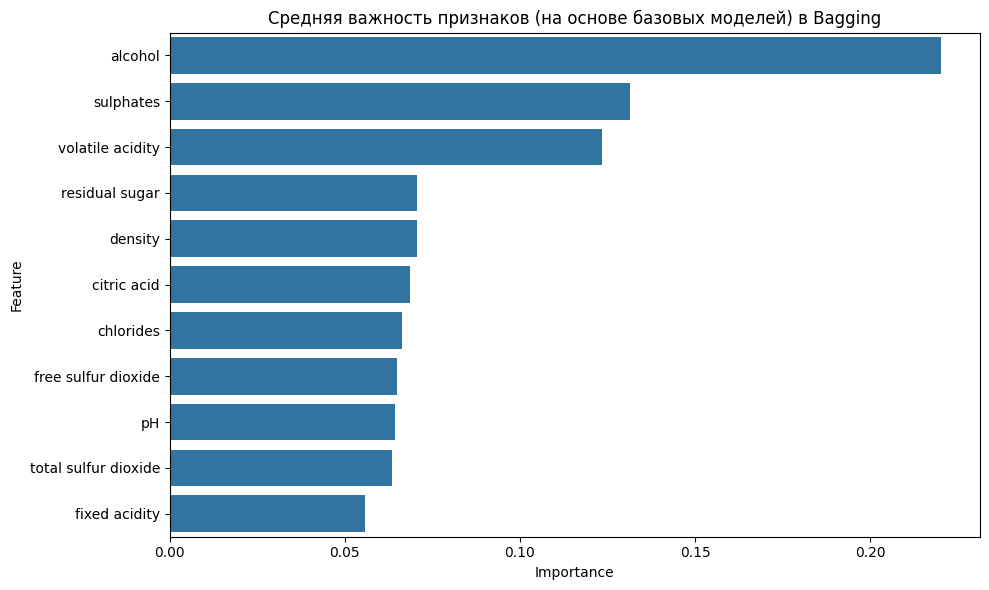

In [55]:
# Визуализация важности признаков для лучшей модели
best_model_name = metrics_df.loc[metrics_df['F1-score'].idxmax(), 'Model']
best_model = models[best_model_name]

# Для бэггинга можно взять важность признаков из базовых моделей
importances = np.mean([tree.feature_importances_ for tree in best_model.estimators_], axis=0)
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': importances
}).sort_values('Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importance)
plt.title(f'Средняя важность признаков (на основе базовых моделей) в {best_model_name}')
plt.tight_layout()
plt.show()

Объяснение для каждого пункта лабораторной работы:

**Задача:** Обучить 5 разных ансамблевых алгоритмов и сравнить их.
**Используемые модели:**

1. **Бэггинг (`BaggingClassifier`)**
    
    - Основан на множестве **независимых решающих деревьев**, обученных на разных подвыборках.
        
    - Уменьшает дисперсию (переобучение).
        
2. **Случайный лес (`RandomForestClassifier`)**
    
    - Улучшенный бэггинг: каждое дерево обучается на **случайном подмножестве признаков**.
        
    - Хорошо работает "из коробки", устойчив к шуму.
        
3. **Сверхслучайные деревья (`ExtraTreesClassifier`)**
    
    - Ещё более случайный вариант: **разбиения в узлах также выбираются случайно**.
        
    - Быстрее случайного леса, но иногда менее точен.
        
4. **AdaBoost (`AdaBoostClassifier`)**
    
    - Последовательно обучает **слабые модели** (обычно неглубокие деревья), увеличивая вес ошибочных примеров.
        
    - Фокусируется на сложных случаях.
        
5. **Градиентный бустинг (`GradientBoostingClassifier`)**
    
    - Оптимизирует ошибку с помощью **градиентного спуска**, строя каждое новое дерево для исправления ошибок предыдущих.
        
    - Часто даёт лучшую точность, но требует аккуратной настройки.
        

**Параметры:**

- `n_estimators=100` — количество деревьев/моделей в ансамбле.
    
- `random_state=42` — для воспроизводимости результатов.
    

---

#### **3. Оценка качества моделей**

**Метрики:**

- **Accuracy** (доля правильных ответов) — простая, но может быть misleading при дисбалансе классов.
    
- **F1-score** — баланс между precision (точность) и recall (полнота), лучше для несбалансированных данных.
    
- **Confusion matrix** — показывает, сколько примеров каждого класса было предсказано верно/неверно.
    

**Визуализации:**

- **Barplot** для сравнения `Accuracy` и `F1-score` всех моделей.
    
- **График важности признаков** для лучшей модели (какие параметры вина сильнее всего влияют на качество).
    

---

#### **4. Сравнение моделей и выводы**

**Как интерпретировать результаты?**

1. **Какая модель лучше?**
    
    - Смотрим на **F1-score** (важнее, чем accuracy, если классы несбалансированы).
        
    - Градиентный бустинг и случайный лес обычно лидируют.
        
2. **Почему AdaBoost может показать худший результат?**
    
    - AdaBoost чувствителен к шуму в данных.
        
    - Возможно, нужно подбирать параметры (глубину деревьев, learning rate).
        
3. **Какие признаки важны?**
    
    - Например, если `alcohol` и `volatile acidity` в топе — это согласуется с экспертизой вина.
        

**Что можно улучшить?**

- Подбор гиперпараметров (`GridSearchCV`).
    
- Использование кросс-валидации.
    
- Попробовать другие ансамбли (XGBoost, LightGBM).